# Programming Assignment #2: Improved CNN for CIFAR-10

### Name: Xiangyu Zeng

This notebook builds a convolutional neural network layer by layer. It does not
import a pre-built architecture from `keras.applications`.


## Improvements made

Compared with the starter CNN, this version adds:

1. Pixel normalization and a reproducible train/validation split.
2. On-the-fly data augmentation: horizontal flips and translations.
3. Three convolutional blocks with six convolution layers.
4. Batch normalization between every `Conv2D`/`Dense` layer and its activation.
5. Dropout before the following trainable layer to reduce overfitting.
6. L2 weight regularization and global average pooling.
7. Adam optimization, learning-rate reduction, early stopping, and best-weight restoration.
8. Final training on all 50,000 training images before one-time test evaluation.


## 1. Data preparation


### 1.1 Load CIFAR-10 and configure reproducibility


In [1]:
import os
import random
from io import BytesIO
from pathlib import Path

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers, regularizers

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Available devices:", tf.config.list_physical_devices())

train_parquet = Path("data/cifar10_train.parquet")
test_parquet = Path("data/cifar10_test.parquet")


def load_parquet_split(path):
    import pyarrow.parquet as pq
    from PIL import Image

    table = pq.read_table(path, columns=["img", "label"])
    image_records = table.column("img").to_pylist()
    images = np.stack(
        [
            np.asarray(Image.open(BytesIO(record["bytes"])).convert("RGB"))
            for record in image_records
        ]
    )
    labels = np.asarray(table.column("label")).reshape(-1, 1)
    return images, labels


if train_parquet.exists() and test_parquet.exists():
    print("Loading the local University of Toronto CIFAR-10 parquet mirror.")
    x_train_raw, y_train = load_parquet_split(train_parquet)
    x_test_raw, y_test = load_parquet_split(test_parquet)
else:
    print("Local parquet mirror not found; using keras.datasets.cifar10.")
    from tensorflow.keras.datasets import cifar10

    (x_train_raw, y_train), (x_test_raw, y_test) = cifar10.load_data()

print("shape of x_train:", x_train_raw.shape)
print("shape of y_train:", y_train.shape)
print("shape of x_test:", x_test_raw.shape)
print("shape of y_test:", y_test.shape)
print("number of classes:", int(np.max(y_train) - np.min(y_train) + 1))


/Users/yuandai/Documents/New project/cs583-programming2/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow version: 2.18.1
Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Loading the local University of Toronto CIFAR-10 parquet mirror.


shape of x_train: (50000, 32, 32, 3)
shape of y_train: (50000, 1)
shape of x_test: (10000, 32, 32, 3)
shape of y_test: (10000, 1)
number of classes: 10


### 1.2 One-hot encode the labels

`to_one_hot` converts an $n\times1$ label array into an $n\times10$ matrix.


In [2]:
def to_one_hot(y, num_class=10):
    y = np.asarray(y).reshape(-1).astype("int64")
    return np.eye(num_class, dtype="float32")[y]


y_train_vec = to_one_hot(y_train)
y_test_vec = to_one_hot(y_test)

print("Shape of y_train_vec:", y_train_vec.shape)
print("Shape of y_test_vec:", y_test_vec.shape)
print("First scalar label:", y_train[0])
print("First one-hot label:", y_train_vec[0])


Shape of y_train_vec: (50000, 10)
Shape of y_test_vec: (10000, 10)
First scalar label: [0]
First one-hot label: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### 1.3 Normalize pixels and create training/validation sets


In [3]:
# Convert integer pixels from [0, 255] to floating-point values in [0, 1].
x_train = x_train_raw.astype("float32") / 255.0
x_test = x_test_raw.astype("float32") / 255.0

# Reproducible random 40K/10K split. The test set remains untouched.
rand_indices = np.random.default_rng(SEED).permutation(len(x_train))
train_indices = rand_indices[:40000]
valid_indices = rand_indices[40000:]

x_tr = x_train[train_indices]
y_tr = y_train_vec[train_indices]
x_val = x_train[valid_indices]
y_val = y_train_vec[valid_indices]

print("Shape of x_tr:", x_tr.shape)
print("Shape of y_tr:", y_tr.shape)
print("Shape of x_val:", x_val.shape)
print("Shape of y_val:", y_val.shape)
print("Pixel range:", float(x_tr.min()), "to", float(x_tr.max()))


Shape of x_tr: (40000, 32, 32, 3)
Shape of y_tr: (40000, 10)
Shape of x_val: (10000, 32, 32, 3)
Shape of y_val: (10000, 10)
Pixel range: 0.0 to 1.0


## 2. Build and tune an improved CNN

The model uses a compact VGG-style design. Data augmentation is active only
during training. Batch normalization is deliberately placed before each ReLU,
as required by the assignment.


In [4]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomTranslation(0.10, 0.10, fill_mode="reflect", seed=SEED),
    ],
    name="data_augmentation",
)


def add_conv_bn_relu(model, filters, dropout_rate=0.0):
    # Per assignment instructions, Dropout regularizes the following Conv2D.
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))
    model.add(
        layers.Conv2D(
            filters,
            kernel_size=3,
            padding="same",
            use_bias=False,
            kernel_initializer="he_normal",
            kernel_regularizer=regularizers.l2(1e-4),
        )
    )
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))


def build_model():
    model = keras.Sequential(name="improved_cifar10_cnn")
    model.add(layers.Input(shape=(32, 32, 3)))
    model.add(data_augmentation)

    # Block 1: 32x32 -> 16x16
    add_conv_bn_relu(model, 32)
    add_conv_bn_relu(model, 32, dropout_rate=0.05)
    model.add(layers.MaxPooling2D(pool_size=2))

    # Block 2: 16x16 -> 8x8
    add_conv_bn_relu(model, 64, dropout_rate=0.10)
    add_conv_bn_relu(model, 64, dropout_rate=0.10)
    model.add(layers.MaxPooling2D(pool_size=2))

    # Block 3: 8x8 -> 4x4
    add_conv_bn_relu(model, 128, dropout_rate=0.15)
    add_conv_bn_relu(model, 128, dropout_rate=0.15)
    model.add(layers.MaxPooling2D(pool_size=2))

    # Global pooling greatly reduces parameters compared with Flatten.
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dropout(0.25))
    model.add(
        layers.Dense(
            128,
            use_bias=False,
            kernel_initializer="he_normal",
            kernel_regularizer=regularizers.l2(1e-4),
        )
    )
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))
    model.add(layers.Dropout(0.35))
    model.add(layers.Dense(10, activation="softmax"))
    return model


model = build_model()
model.summary()


I0000 00:00:1783871170.540827  551362 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1783871170.542193  551362 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "improved_cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 306,538 (1.17 MB)

 Trainable params: 305,386 (1.16 MB)

 Non-trainable params: 1,152 (4.50 KB)

### 2.1 Compile and tune using only the validation set


In [5]:
INITIAL_LEARNING_RATE = 1e-3
BATCH_SIZE = 256
TUNING_EPOCHS = int(os.getenv("TUNING_EPOCHS", "18"))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=INITIAL_LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

tuning_callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        "best_tuned_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    x_tr,
    y_tr,
    batch_size=BATCH_SIZE,
    epochs=TUNING_EPOCHS,
    validation_data=(x_val, y_val),
    callbacks=tuning_callbacks,
    verbose=2,
)


Epoch 1/18



Epoch 1: val_accuracy improved from -inf to 0.21600, saving model to best_tuned_model.keras


157/157 - 51s - 327ms/step - accuracy: 0.3261 - loss: 1.9604 - val_accuracy: 0.2160 - val_loss: 2.5668 - learning_rate: 1.0000e-03


Epoch 2/18



Epoch 2: val_accuracy improved from 0.21600 to 0.43820, saving model to best_tuned_model.keras


...

157/157 - 31s - 195ms/step - accuracy: 0.7806 - loss: 0.7405 - val_accuracy: 0.8025 - val_loss: 0.6681 - learning_rate: 5.0000e-04


Epoch 18/18



Epoch 18: val_accuracy improved from 0.80250 to 0.80360, saving model to best_tuned_model.keras


157/157 - 32s - 202ms/step - accuracy: 0.7851 - loss: 0.7278 - val_accuracy: 0.8036 - val_loss: 0.6666 - learning_rate: 5.0000e-04


Restoring model weights from the end of the best epoch: 18.


### 2.2 Plot learning curves and report tuned-model accuracy


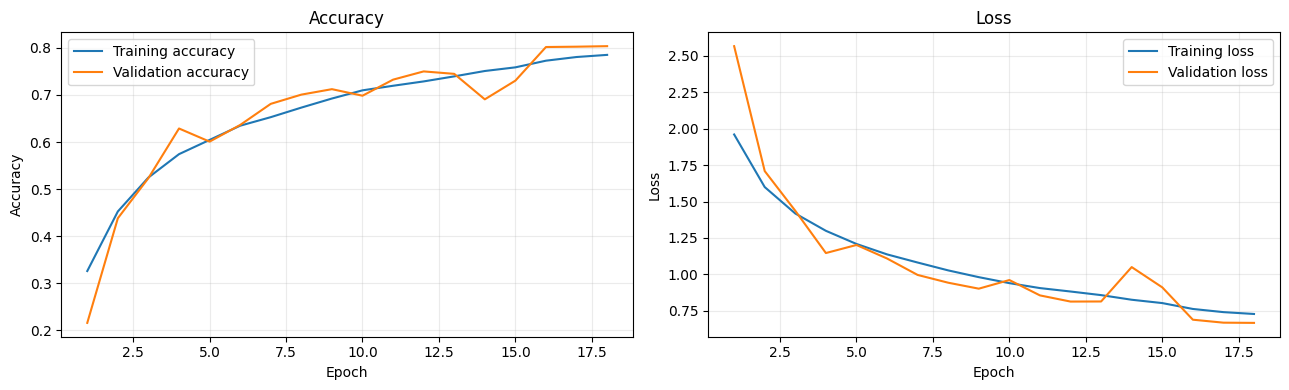

Best validation epoch: 18
Training accuracy:   0.8183
Validation accuracy: 0.8036


In [6]:
def plot_history(history):
    train_acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    train_loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(train_acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(epochs, train_acc, label="Training accuracy")
    axes[0].plot(epochs, val_acc, label="Validation accuracy")
    axes[0].set(xlabel="Epoch", ylabel="Accuracy", title="Accuracy")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].plot(epochs, train_loss, label="Training loss")
    axes[1].plot(epochs, val_loss, label="Validation loss")
    axes[1].set(xlabel="Epoch", ylabel="Loss", title="Loss")
    axes[1].grid(alpha=0.25)
    axes[1].legend()
    plt.tight_layout()
    plt.show()


plot_history(history)

train_loss, train_accuracy = model.evaluate(x_tr, y_tr, verbose=0)
val_loss, val_accuracy = model.evaluate(x_val, y_val, verbose=0)
best_epoch = int(np.argmax(history.history["val_accuracy"]) + 1)

print(f"Best validation epoch: {best_epoch}")
print(f"Training accuracy:   {train_accuracy:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")


## 3. Final training on all 50,000 training images

After hyper-parameters have been selected without using the test set, the best
tuned model is fine-tuned on all 50,000 available training images. The test set
is evaluated only once at the end.


In [7]:
# Reload the checkpoint with the best validation accuracy.
model = keras.models.load_model("best_tuned_model.keras")

# Recompile with the same optimizer family and a smaller learning rate for
# stable full-data fine-tuning.
FINAL_LEARNING_RATE = 2e-4
FINAL_EPOCHS = int(os.getenv("FINAL_EPOCHS", "5"))
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=FINAL_LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

final_history = model.fit(
    x_train,
    y_train_vec,
    batch_size=BATCH_SIZE,
    epochs=FINAL_EPOCHS,
    callbacks=[
        keras.callbacks.ReduceLROnPlateau(
            monitor="loss", factor=0.5, patience=3, min_lr=1e-5, verbose=1
        )
    ],
    verbose=2,
)


Epoch 1/5


196/196 - 63s - 323ms/step - accuracy: 0.7894 - loss: 0.7090 - learning_rate: 2.0000e-04


Epoch 2/5


196/196 - 47s - 239ms/step - accuracy: 0.7958 - loss: 0.6977 - learning_rate: 2.0000e-04


Epoch 3/5


196/196 - 47s - 239ms/step - accuracy: 0.7971 - loss: 0.6851 - learning_rate: 2.0000e-04


Epoch 4/5


196/196 - 50s - 253ms/step - accuracy: 0.8012 - loss: 0.6784 - learning_rate: 2.0000e-04


Epoch 5/5


196/196 - 36s - 182ms/step - accuracy: 0.7994 - loss: 0.6753 - learning_rate: 2.0000e-04


## 4. Final evaluation and assignment answers


In [8]:
final_train_loss, final_train_accuracy = model.evaluate(
    x_train, y_train_vec, verbose=0
)
test_loss, test_accuracy = model.evaluate(x_test, y_test_vec, verbose=0)

print("FINAL RESULTS")
print("-------------")
print(f"Training accuracy:   {final_train_accuracy:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")
print(f"Test accuracy:       {test_accuracy:.4f}")
print(f"Test loss:           {test_loss:.4f}")


FINAL RESULTS
-------------
Training accuracy:   0.8373
Validation accuracy: 0.8036
Test accuracy:       0.8134
Test loss:           0.6419


### Essay answer: What improvements have you made?

I normalized the image pixels and replaced the shallow starter network with a
six-convolution-layer, three-block CNN built layer by layer. I added online data
augmentation, batch normalization between each trainable layer and activation,
dropout before subsequent trainable layers, L2 weight regularization, and global
average pooling. I also used Adam optimization with automatic learning-rate
reduction, early stopping, checkpointing, and final fine-tuning on all 50,000
training images. Hyper-parameters were selected using the validation set only;
the test set was reserved for the final evaluation.

The exact training, validation, and test accuracies are printed in the final
code cell above.
